In [12]:
# для работы с многомерными массивами и научными вычислениями
import numpy as np 
# для работы с итераторами
import itertools
#  для построения графиков
from matplotlib import pylab 
# библиотека для интерактивной визуализации данных.
import plotly.graph_objs as go 
from plotly.offline import iplot,init_notebook_mode
# iplot — функция для отображения интерактивных графиков прямо в блокноте 
# init_notebook_mode() — включает оффлайн-режим Plotly для работы внутри блокнота
init_notebook_mode(connected=True)

#Класс реализующий простую нейронную сеть
class network:
    # в конструкторе создаётся массив весов размером size+1 (доп. вес для смещения)
    def __init__(self,size): # self - ссылка на сам объект-экземпляр класса
        self.weights=np.zeros(size + 1) # задаём нулевые веса в атрибуте объекта weights
    
    # Функция активации (пороговая)
    def activation_function(self, x):
        return int(x >= 0)
    
    # Производная пороговой ФА
    def deviation_activation_function(self,x):
        return 1    
     
    # Функция предсказания 
    def predict(self,net):
        return int(self.activation_function(net) >= 0.5) 
        
    # Функция обучения нейросети с использованием дельта-правила Видроу-Хоффа
    def learn(self, inputs, outputs, show=False):
            eta = 0.3 # норма обучения
            if show == True: # вывод результатов на каждом шаге обучения
                out=[]
                k=1 # 1-ая эпоха
                E = 1000 
                # пока ошибка не станет нулевой или пока число итераций < 100
                while E > 0 and k < 100:
                    predict_outputs = []   
                    E = 0 # обнуляем расстояние Хэмминга перед новой эпохой
                    
                    # Сохраняем веса перед началом эпохи
                    weights_before_epoch = np.copy(self.weights)
                    
                    for I_input in range(len(inputs)): # переход ОТ ШАГА К ШАГУ по обучающей выборке
                        # Вставляем "1" в позицию 0)
                        single_input = np.insert(inputs[I_input], 0, 1)  
                        # вычисляем комбинированный вход
                        net = np.dot(single_input,self.weights) 
                        # вычисляем прогнозируемый выход ФА для данного набора данных на входе
                        single_predict_output = self.predict(net) 
                        predict_outputs.append(single_predict_output)
                        # ошибка, которая является разницей между целевыми выходами и предсказанными.
                        delta = outputs[I_input] - single_predict_output 
                        # расстояние Хэмминга 
                        E += abs(delta)  
                        # Коррекция весов на основе ошибки (вектор delta(w)) 
                        # correction=eta * delta * np.insert(inputs[I_input], 0, 1) 
                        correction=eta * delta * self.deviation_activation_function(net) * np.insert(inputs[I_input], 0, 1)      
                        self.weights += correction # w + delta(w)
                    # сохраняем результат эпохи
                    out.append([k,np.round(weights_before_epoch, 3), np.array(outputs, dtype=int), predict_outputs, E])
                    # переходим к следующей эпохе
                    k+=1   
                return out
            
            else: # то же самое, но без сохранения промежуточных результатов для вывода
                k=1 # 1-ая эпоха
                E = 1000
                while E > 0 and k < 100:   
                    E = 0 # обнуляем расстояние Хэмминга перед новой эпохой

                    for I_input in range(len(inputs)): # переход ОТ ШАГА К ШАГУ по обучающей выборке
                        # Вставляем "1" в позицию 0)
                        single_input = np.insert(inputs[I_input], 0, 1)  
                        # вычисляем комбинированный вход
                        net = np.dot(single_input,self.weights)
                        # вычисляем прогнозируемый выход ФА для данного набора данных на входе
                        single_predict_output = self.predict(net) 
                        # ошибка, которая является разницей между целевыми выходами и предсказанными.
                        delta = outputs[I_input] - single_predict_output
                        # расстояние Хэмминга 
                        E += abs(delta)  
                        # Коррекция весов на основе ошибки (вектор delta(w)) 
                        correction=eta * delta * self.deviation_activation_function(net) * np.insert(inputs[I_input], 0, 1)  
                        self.weights += correction # w + delta(w)   
                    # переходим к следующей эпохе
                    k+=1 
                return E

    def check_network_with_weights(self,inputs,outputs):
        E_check = 0
        for I_input in range(len(inputs)): # переход ОТ ШАГА К ШАГУ по обучающей выборке
            # Вставляем "1" в позицию 0)
            single_input = np.insert(inputs[I_input], 0, 1)  
            # вычисляем комбинированный вход
            net = np.dot(single_input,self.weights)
            # вычисляем прогнозируемый выход ФА для данного набора данных на входе
            single_predict_output = self.predict(net) 
            # ошибка, которая является разницей между целевыми выходами и предсказанными.
            delta = outputs[I_input] - single_predict_output
            # расстояние Хэмминга 
            E_check += abs(delta)  
        return E_check


In [13]:
#Задание исходных данных
def bool_func(x):
    return not(not( x[0] or x[1] ) or x[2] or x[3])
    # return (not (x[0] and x[1])) and x[2] and x[3]
    # return (x[0] or x[1]) and x[2] and x[3]
# Инициализация списков входных и выходных данных
full_inputs=[]
full_outputs=[]
for i in range(16):
    full_inputs.append(list(map(int, bin(i)[2:].rjust(4,'0'))))
    # list(map(int, ...)) — перевод строки из '0' и '1' в список целых чисел: [0, 0, 1, 0]
    # bin(i)[2:] - перевод i в двоичный вид без префикса 0b (срез, начиная со второго символа)
    # .rjust(4,'0') - дополнение слева нулями до 4 бит
for i in full_inputs:
    full_outputs.append(bool_func(i))
full_inputs = np.array(full_inputs)
full_outputs = np.array(full_outputs)

#Вывод таблицы истинности
print("Таблица истинности:")
# zip() — соединяет входы и выходы парами.
for i,j in zip(full_inputs, full_outputs): 
    print(i, int(j))


Таблица истинности:
[0 0 0 0] 0
[0 0 0 1] 0
[0 0 1 0] 0
[0 0 1 1] 0
[0 1 0 0] 1
[0 1 0 1] 0
[0 1 1 0] 0
[0 1 1 1] 0
[1 0 0 0] 1
[1 0 0 1] 0
[1 0 1 0] 0
[1 0 1 1] 0
[1 1 0 0] 1
[1 1 0 1] 0
[1 1 1 0] 0
[1 1 1 1] 0


In [14]:
#Обучение сети на всех данных
netw=network(4) # создаётся объект класса network, который представляет нейронную сеть с 4 входами.

out=netw.learn(full_inputs,full_outputs,show=True) # обучаем нейронную сеть на всех данных

#Вывод результатов
# создаём таблицу с помощью библиотеки Plotly для визуализации:
trace = go.Table(
    # header — определяет названия колонок в таблице
    header = dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Ожидаемый вектор y',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    
    # cells — создаём ячейки для данных, используя zip(*output); 
    # каждый столбец данных (эпохи) транспонируется
    cells = dict(values = [*list(zip(*out))]) 
)
data = [trace] 
iplot(data, filename = 'basic_table') # отображает таблицу в Jupyter Notebook с помощью Plotly


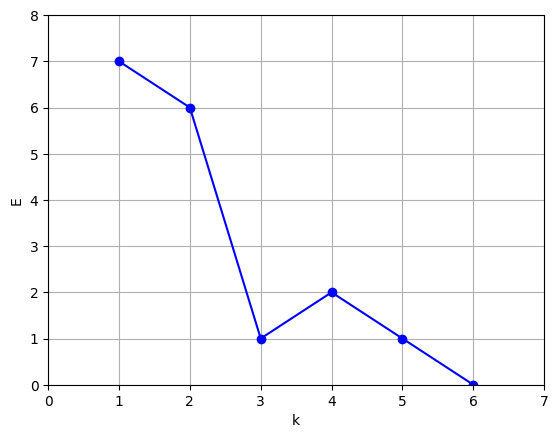

In [15]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Пороговая функция, все данные

# output - спсиок, где каждая запись - информация о текущей эпохе
# i[-1] - последний элемент записи (кортежа) - значение суммар. ошибки
E=[i[-1] for i in out] # из результата обучения извлекается ошибка
k=[j[0] for j in out] # извлечение номера эпохи
pylab.plot(k,E,'-ob') # строим график: 'o' — круги, 'b' — синий цвет
pylab.xlabel('k') # номер эпохи
pylab.ylabel('E') # ошибка
pylab.grid(True)
pylab.axis([0, len(k)+1, 0, max(E)+1])
pylab.show()


In [16]:
#Класс для сети с сигмоидальной функцией активации
class sigma_network(network):

    # Функция активации (сигмоидальная)
    def activation_function(self, net):
        return (1 / (1 + np.exp(-net)))

    # Производная ФА
    def deviation_activation_function(self, net):
        sig = self.activation_function(net)
        return (sig * (1 - sig))
            
#обучение сети с сигмоидальной функцией на всех данных
sigma_netw=sigma_network(4)
out_sigma = sigma_netw.learn(full_inputs,full_outputs,show=True)

#вывод результатов
trace = go.Table(
    header=dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Ожидаемый вектор y',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    cells=dict(values=[*list(zip(*out_sigma))])
)
data = [trace] 
iplot(data, filename = 'basic_table')


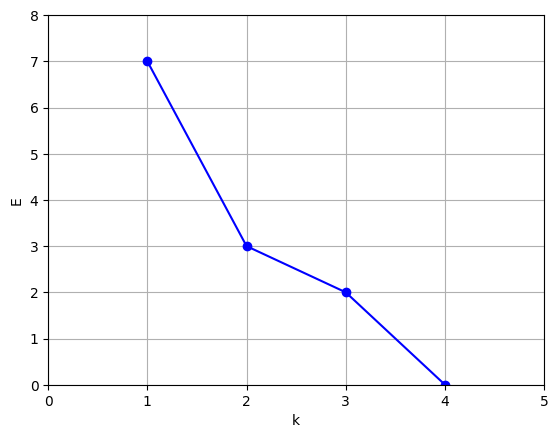

In [17]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Сигмоидальная функция, все данные
E=[i[-1] for i in out_sigma] # из результата обучения извлекается ошибка
k=[j[0] for j in out_sigma] # извлечение номера эпохи
pylab.plot(k,E,'-ob') # строим график: 'o' — круги, 'b' — синий цвет
pylab.xlabel('k') # номер эпохи
pylab.ylabel('E') # ошибка
pylab.grid(True)
pylab.axis([0, len(k)+1, 0, max(E)+1])
pylab.show()


In [18]:
#Функция для нахождения минимальных входных данных для сети, достаточных для обучения
def find_min_inputs(full_inputs, full_outputs, network):
        for i in range(1,len(full_inputs)): # Перебор подмножеств от 1 до 15
            new_inputs = itertools.combinations(range(16), i)
            # перебор всех возможных сочетаний индексов входов длиной i 
            for sample in new_inputs: 
                inputs=[]
                outputs=[]
                min_output = []
                for number in sample:
                    # формируем двоичное представление числа (4-битное)
                    inputs.append(list(map(int,bin(number)[2:].rjust(4,'0'))))
                for bin_number in inputs:
                    # генерируем выходы для поднабора входов через булеву функцию
                    outputs.append(bool_func(bin_number))
                inputs = np.array(inputs)
                outputs = np.array(outputs)

                netw = network(4)
                # Обучение сети на выбранном подмножестве
                E = netw.learn(inputs, outputs) 
                # Расстояние Хэмминга при тестировании на полном наборе
                E_full = netw.check_network_with_weights(full_inputs, full_outputs)
                print("E_min: ",E,"E_full: ",E_full)
                # Проверка, способна ли сеть корректно предсказывать на множестве
                if E == 0 and E_full == 0:
                    min_input_param={'weights': netw.weights,'inputs': inputs, 'outputs':outputs}
                    return min_input_param
            
min_input_param = find_min_inputs(full_inputs, full_outputs, network) 
min_weights = np.round(min_input_param['weights'],3)
min_input = min_input_param['inputs']
min_output = np.array(min_input_param['outputs'], dtype = int)

print('Веса:', min_weights)
print('Минимальная выборка:', min_input)
print('Ожидаемый выход:', min_output)

netw_min_train = network(4)
# обучение нейросети на минимальной выборке с ВЫВОДОМ результата
min_out = netw_min_train.learn(min_input,min_output,show=True)

# вывод результатов
trace = go.Table(
    header=dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Ожидаемый вектор y',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    cells=dict(values=[*list(zip(*min_out))])
)
data = [trace]

iplot(data, filename = 'basic_table')


E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  13
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  13
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  13
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  7
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  7
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  9
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  9
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  9
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  11
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  9
E_min:  0

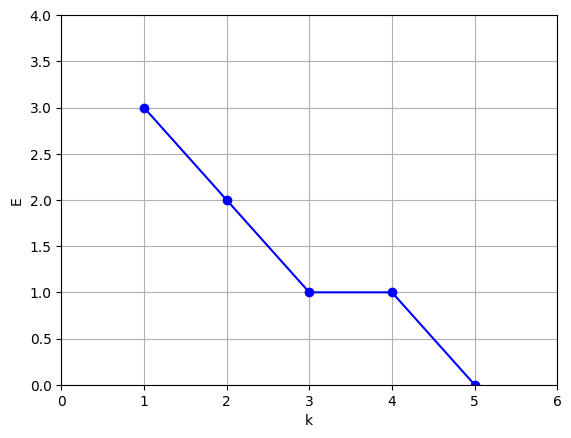

In [19]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Пороговая функция, минимальный набор данных

E=[i[-1] for i in min_out] # из результата обучения извлекается ошибка
k=[j[0] for j in min_out] # извлечение номера эпохи
pylab.plot(k,E,'-ob') # строим график: 'o' — круги, 'b' — синий цвет
pylab.xlabel('k') # номер эпохи
pylab.ylabel('E') # ошибка
pylab.grid(True)
pylab.axis([0, len(k)+1, 0, max(E)+1])
pylab.show()

In [20]:
#Вычисление минимального набора векторов и вывод результатов
#Сигмоидальная функция

min_input_param_s = find_min_inputs(full_inputs, full_outputs, sigma_network) 
min_weights_s = np.round(min_input_param_s['weights'],3)
min_input_s = min_input_param_s['inputs']
min_output_s = np.array(min_input_param_s['outputs'], dtype = int)

print('Веса:', min_weights_s)
print('Минимальная выборка:', min_input_s)
print('Ожидаемый выход:', min_output_s)

sigma_netw_min_train = sigma_network(4)
# обучение нейросети на минимальной выборке с ВЫВОДОМ результата
min_out_s = sigma_netw_min_train.learn(min_input_s,min_output_s,show=True)

# вывод результатов
trace = go.Table(
    header=dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Ожидаемый вектор y',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    cells=dict(values=[*list(zip(*min_out_s))])
)
data = [trace]

iplot(data, filename = 'basic_table')

E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  13
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  13
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  13
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  7
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  7
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  9
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  5
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 E_full:  3
E_min:  0 

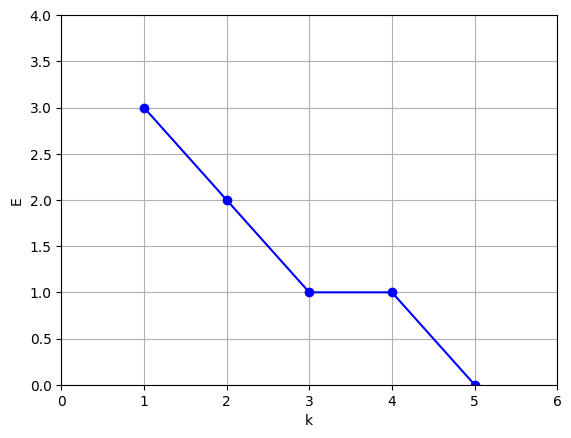

In [21]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Сигмоидальная функция, минимальный набор данных

E=[i[-1] for i in min_out_s] # из результата обучения извлекается ошибка
k=[j[0] for j in min_out_s] # извлечение номера эпохи
pylab.plot(k,E,'-ob') # строим график: 'o' — круги, 'b' — синий цвет
pylab.xlabel('k') # номер эпохи
pylab.ylabel('E') # ошибка
pylab.grid(True)
pylab.axis([0, len(k)+1, 0, max(E)+1])
pylab.show()
